In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

MODEL original
R_SQUARED: 0.02791 ± 0.00305


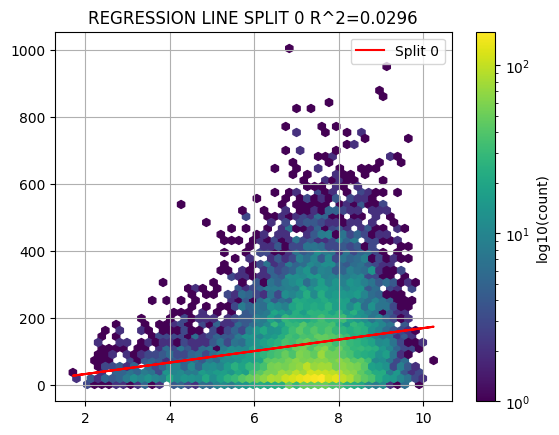

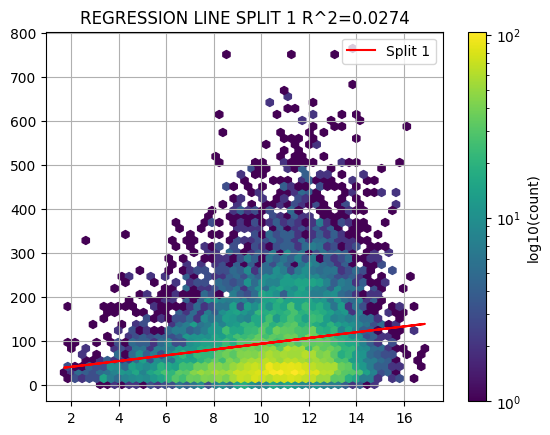

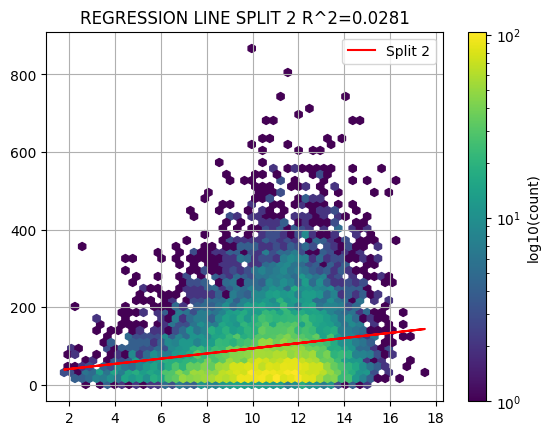

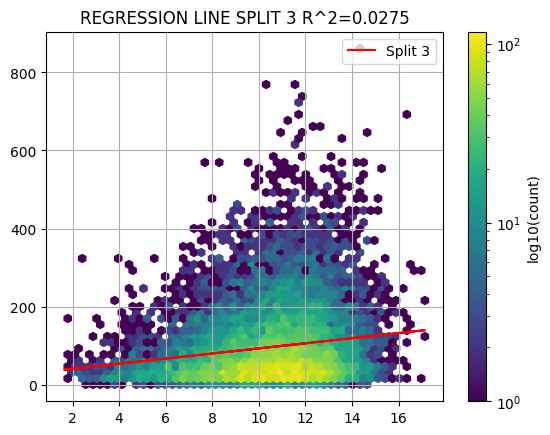

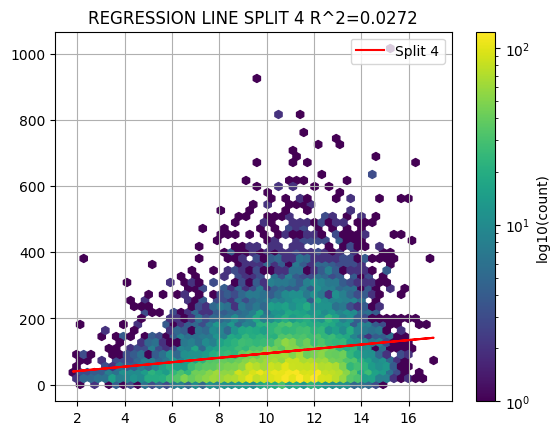

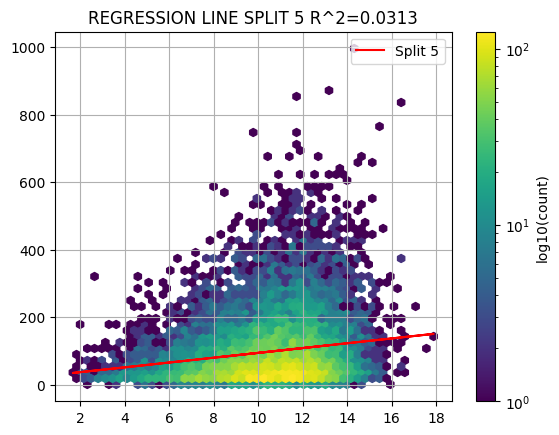

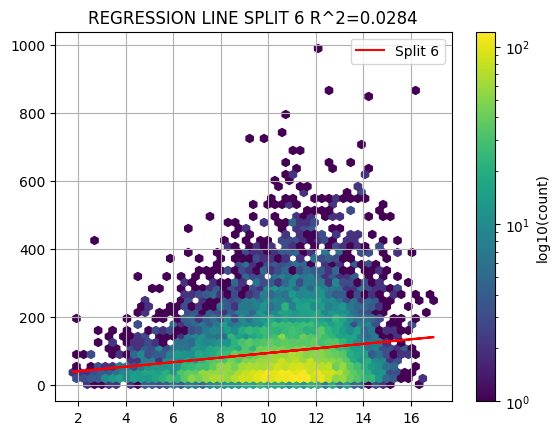

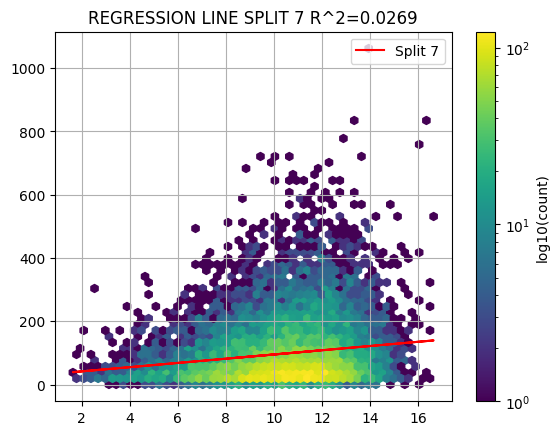

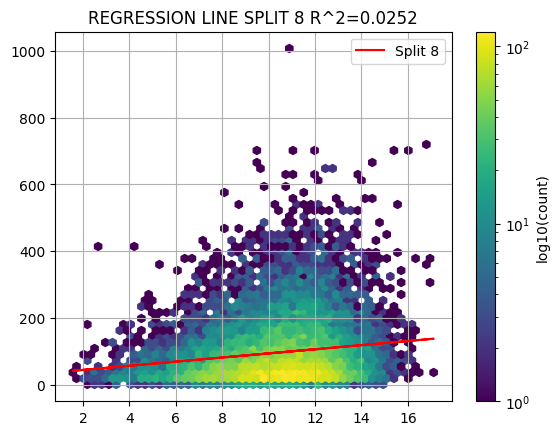

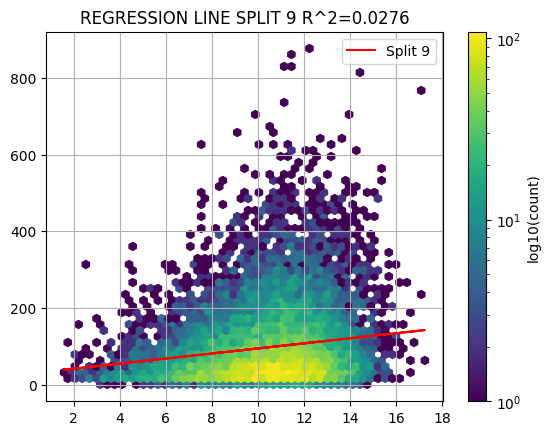

In [7]:
model_name = 'original'

df = pd.read_csv(f'../analysis/sim_analysis/dtw_{model_name}.csv')


rsquared_list = []

space = np.linspace(df['item_dist'].min(), df['item_dist'].max(), 100)

for s in df['split'].unique():
    df_tmp = df[df['split']==s]

    dist = df_tmp['item_dist'].to_numpy()
    prob = df_tmp['score'].to_numpy()
    
    
    dist_sm = sm.add_constant(dist)  
    model = sm.OLS(prob, dist_sm)    
    results = model.fit()     
    rsquared_list.append(results.rsquared)
    plt.figure()
    plt.plot(dist, results.predict(dist_sm), label=f'Split {s}', color='red')
    plt.legend()
    plt.grid()
    plt.title(f'REGRESSION LINE SPLIT {s} R^2={results.rsquared:.4f}')
    # plt.legend()
    plt.hexbin(x=df_tmp['item_dist'], y=df_tmp['score'],gridsize=50, cmap="viridis", bins='log')
    plt.colorbar(label='log10(count)')



print(f'MODEL {model_name}')
print(f'R_SQUARED: {np.mean(rsquared_list):.5f} ± {1.96*np.std(rsquared_list):.5f}')

MODEL extended
R_SQUARED: 0.02615 ± 0.00624


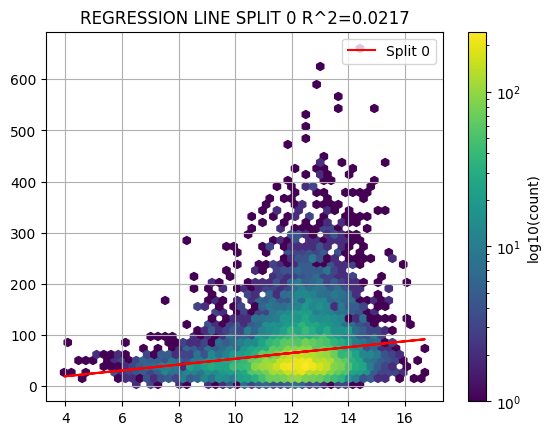

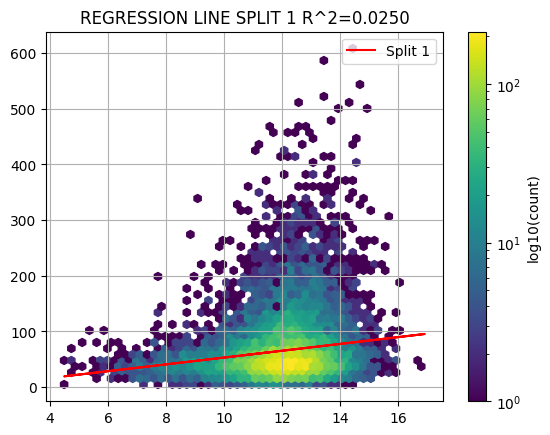

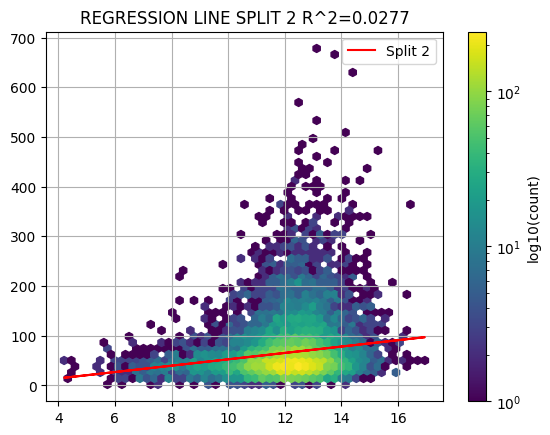

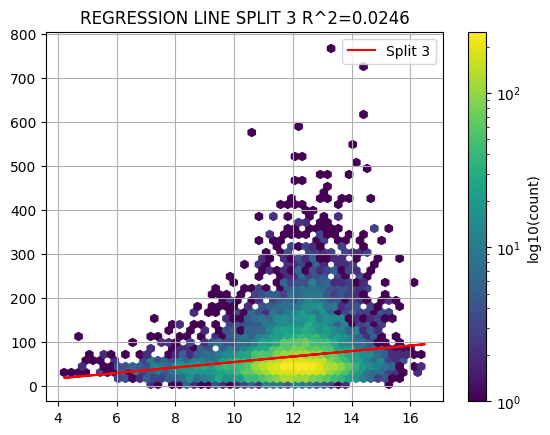

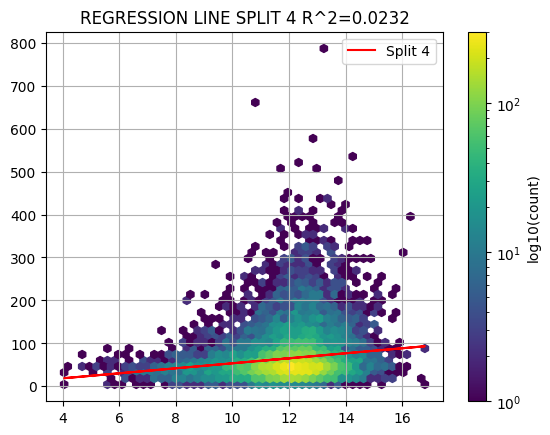

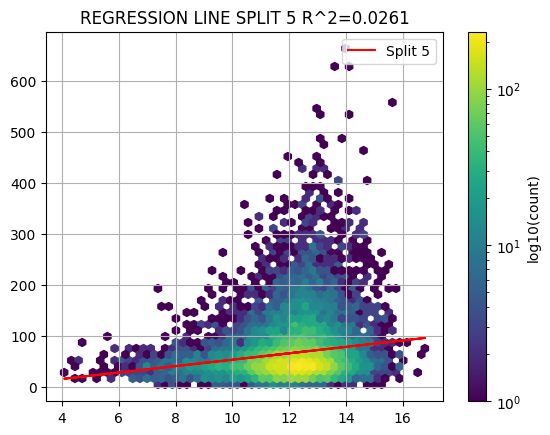

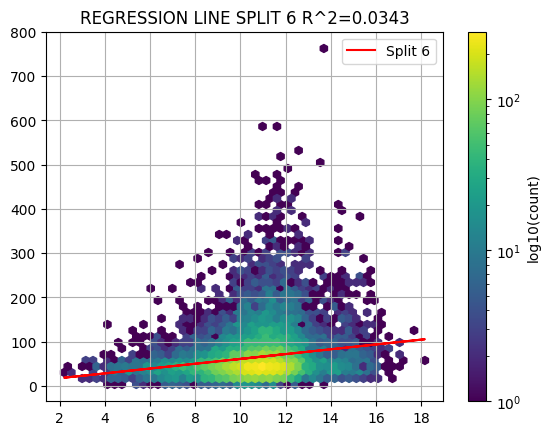

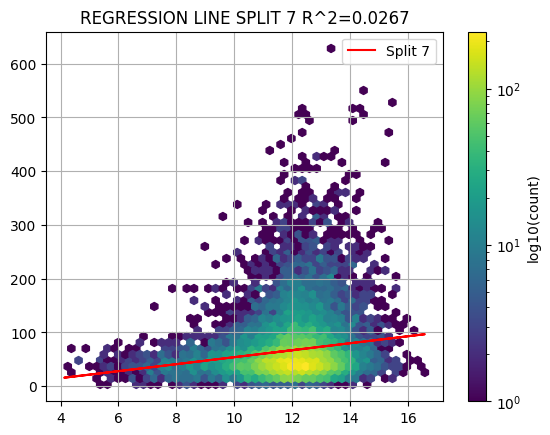

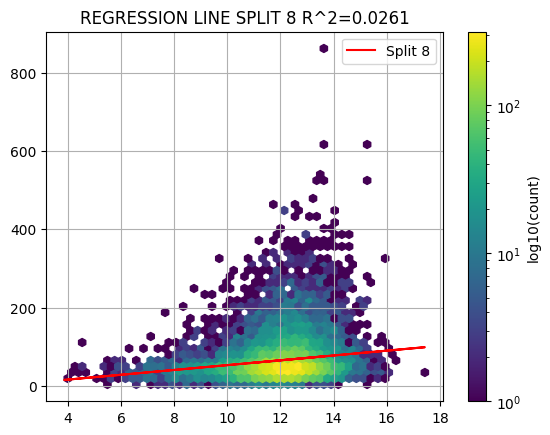

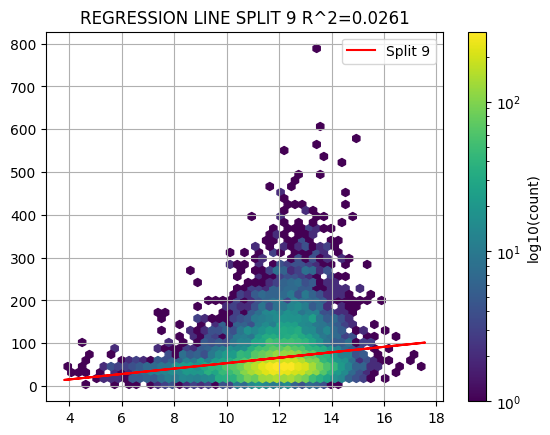

In [8]:
model_name = 'extended'

df = pd.read_csv(f'../analysis/sim_analysis/dtw_{model_name}.csv')


rsquared_list = []

space = np.linspace(df['item_dist'].min(), df['item_dist'].max(), 100)

for s in df['split'].unique():
    df_tmp = df[df['split']==s]

    dist = df_tmp['item_dist'].to_numpy()
    prob = df_tmp['score'].to_numpy()
    
    
    dist_sm = sm.add_constant(dist)  
    model = sm.OLS(prob, dist_sm)    
    results = model.fit()     
    rsquared_list.append(results.rsquared)
    plt.figure()
    plt.plot(dist, results.predict(dist_sm), label=f'Split {s}', color='red')
    plt.legend()
    plt.grid()
    plt.title(f'REGRESSION LINE SPLIT {s} R^2={results.rsquared:.4f}')
    # plt.legend()
    plt.hexbin(x=df_tmp['item_dist'], y=df_tmp['score'],gridsize=50, cmap="viridis", bins='log')
    plt.colorbar(label='log10(count)')



print(f'MODEL {model_name}')
print(f'R_SQUARED: {np.mean(rsquared_list):.5f} ± {1.96*np.std(rsquared_list):.5f}')

MODEL extendedDoubleBase
R_SQUARED BASE: 0.02470 ± 0.00284
R_SQUARED EXT: 0.00033 ± 0.00033


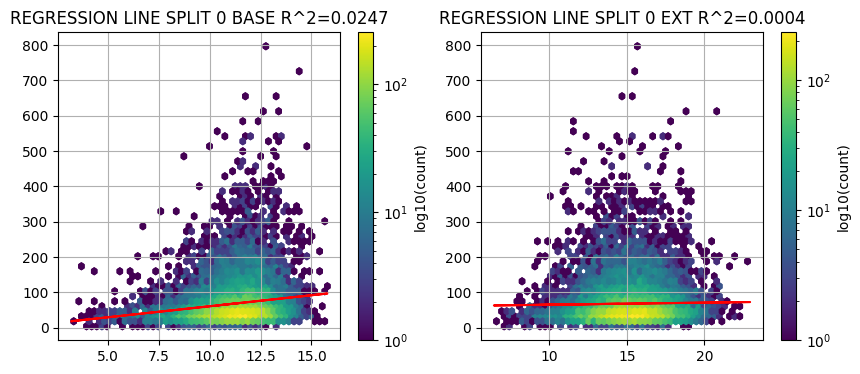

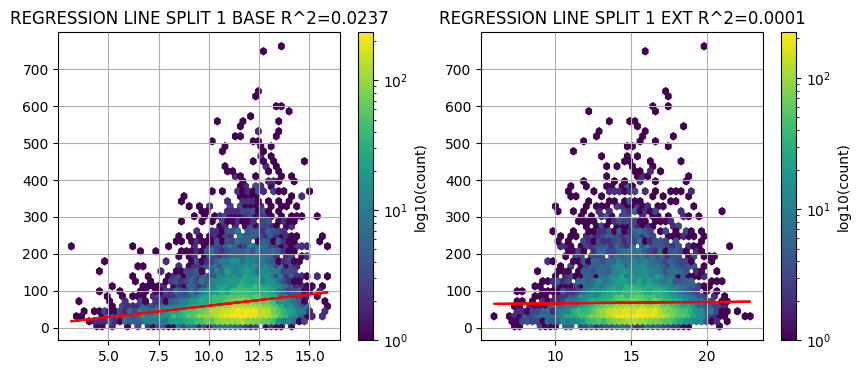

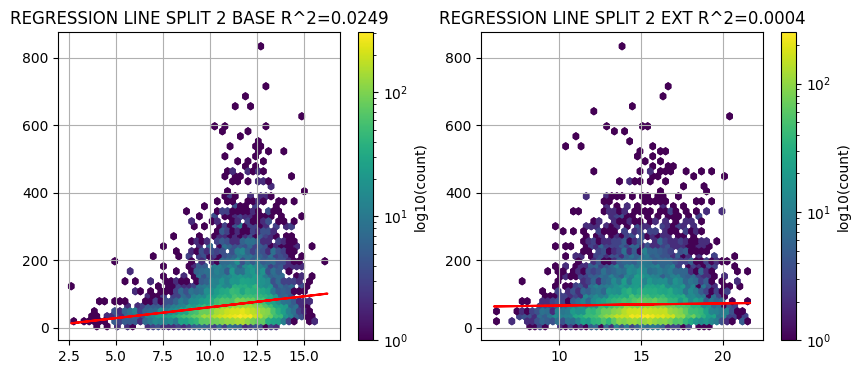

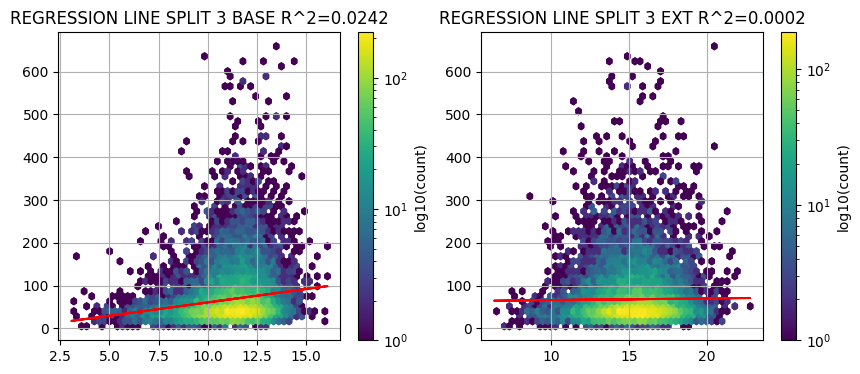

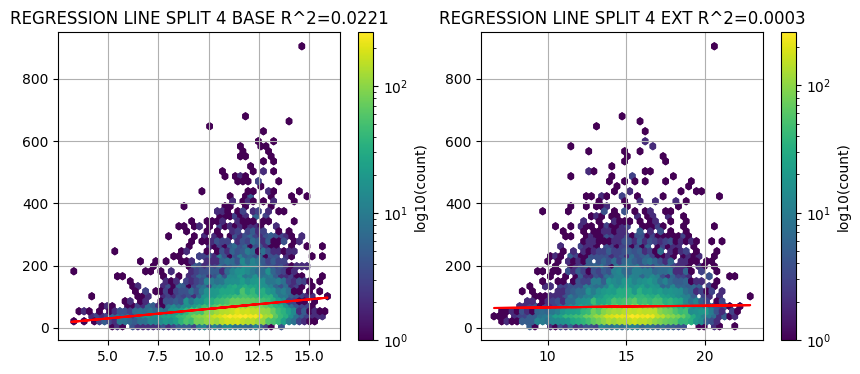

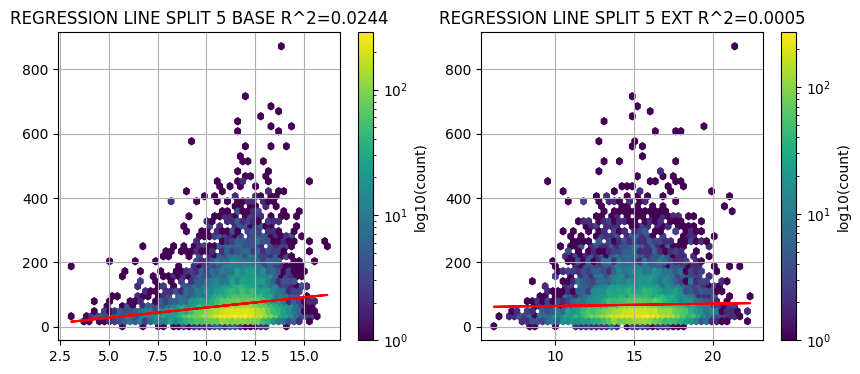

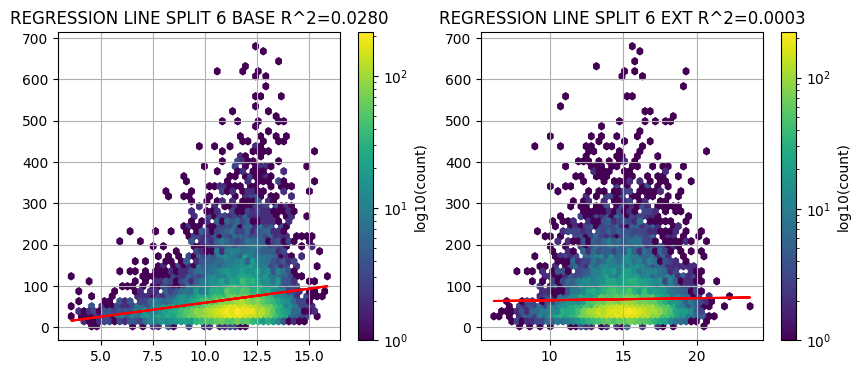

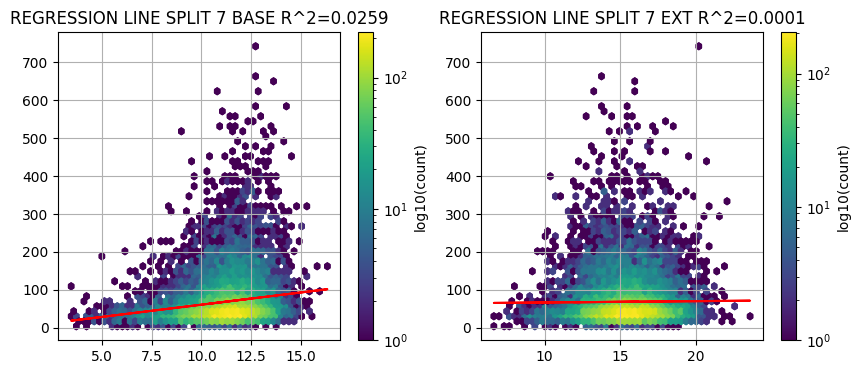

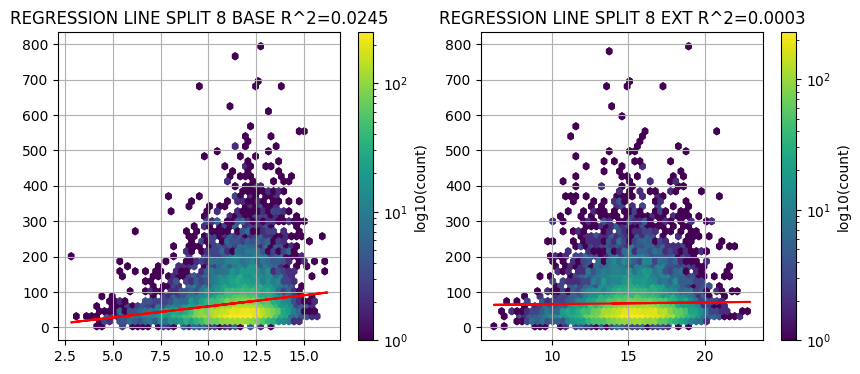

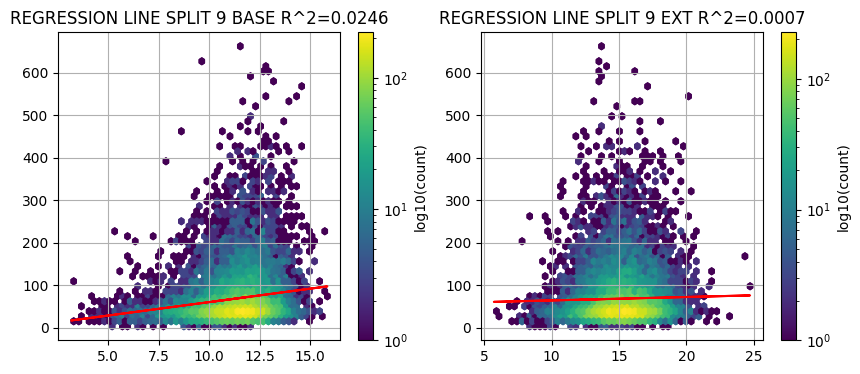

In [10]:
model_name = 'extendedDoubleBase'

df = pd.read_csv(f'../analysis/sim_analysis/dtw_{model_name}.csv')


b_rsquared_list = []
e_rsquared_list = []

for s in df['split'].unique():
    df_tmp = df[df['split']==s]

    b_dist = df_tmp['item_dist_base'].to_numpy()
    e_dist = df_tmp['item_dist_ext'].to_numpy()
    prob = df_tmp['score'].to_numpy()

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    
    b_dist_sm = sm.add_constant(b_dist)  
    b_model = sm.OLS(prob, b_dist_sm)    
    b_results = b_model.fit()     
    b_rsquared_list.append(b_results.rsquared)

    

    
    axes[0].plot(b_dist, b_results.predict(b_dist_sm), label=f'Split {s} base emb', color='red')
    axes[0].grid()
    axes[0].set_title(f'REGRESSION LINE SPLIT {s} BASE R^2={b_results.rsquared:.4f}')
    axes[0].hexbin(x=df_tmp['item_dist_base'], y=df_tmp['score'],gridsize=50, cmap="viridis", bins='log')

    hb = axes[0].hexbin(
                x=df_tmp['item_dist_base'],
                y=df_tmp['score'],
                gridsize=50,
                cmap="viridis",
                bins='log'
            )

    fig.colorbar(hb, ax=axes[0], label='log10(count)')

    
    e_dist_sm = sm.add_constant(e_dist)  
    e_model = sm.OLS(prob, e_dist_sm)    
    e_results = e_model.fit()     
    e_rsquared_list.append(e_results.rsquared)

    

    
    axes[1].plot(e_dist, e_results.predict(e_dist_sm), label=f'Split {s} base ext', color='red')
    axes[1].grid()
    axes[1].set_title(f'REGRESSION LINE SPLIT {s} EXT R^2={e_results.rsquared:.4f}')
    axes[1].hexbin(x=df_tmp['item_dist_ext'], y=df_tmp['score'],gridsize=50, cmap="viridis", bins='log')

    hb = axes[1].hexbin(
                x=df_tmp['item_dist_ext'],
                y=df_tmp['score'],
                gridsize=50,
                cmap="viridis",
                bins='log'
            )

    fig.colorbar(hb, ax=axes[1], label='log10(count)')



print(f'MODEL {model_name}')
print(f'R_SQUARED BASE: {np.mean(b_rsquared_list):.5f} ± {1.96*np.std(b_rsquared_list):.5f}')
print(f'R_SQUARED EXT: {np.mean(e_rsquared_list):.5f} ± {1.96*np.std(e_rsquared_list):.5f}')

MODEL extendedDoubleEmb
R_SQUARED BASE: 0.00296 ± 0.00119
R_SQUARED EXT: 0.00239 ± 0.00064


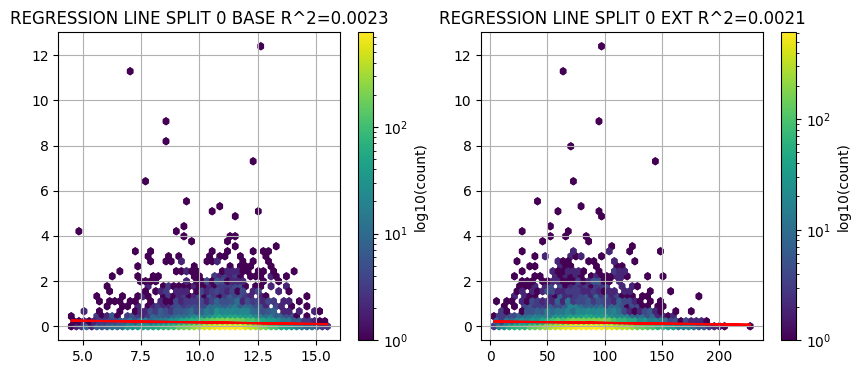

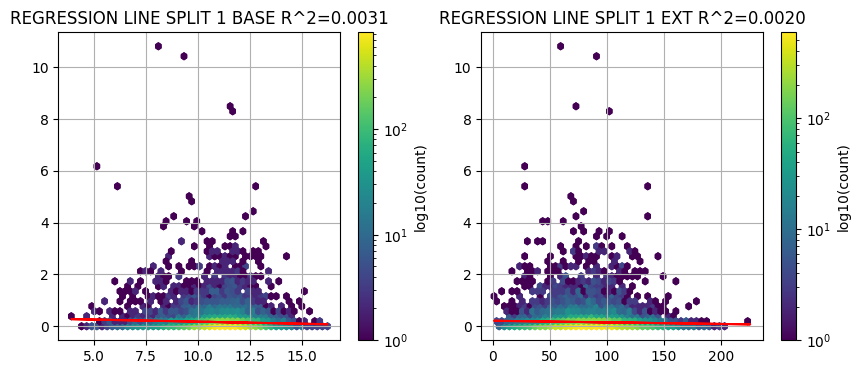

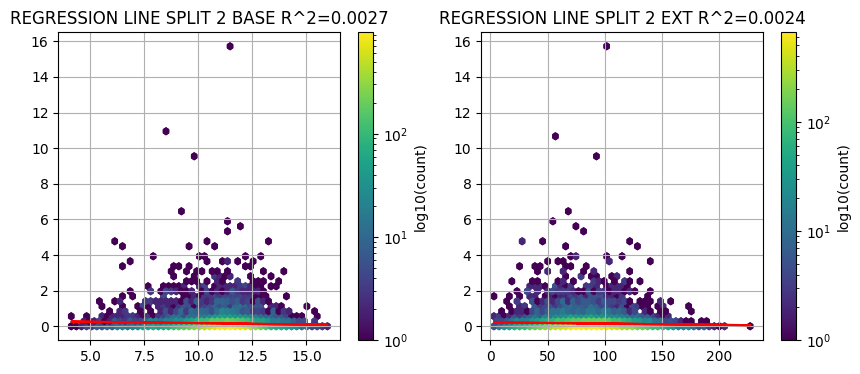

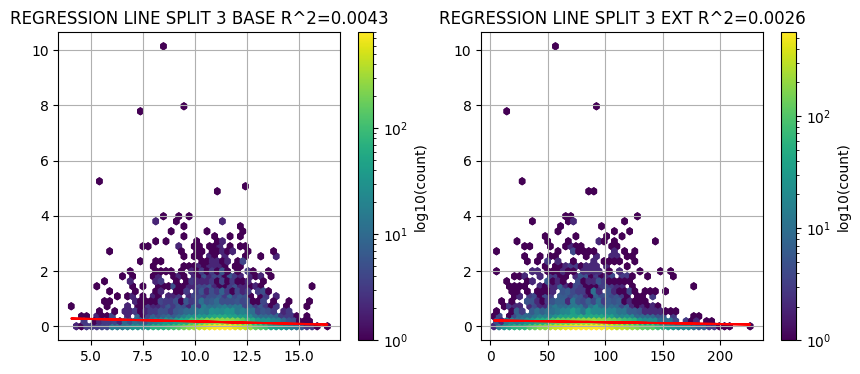

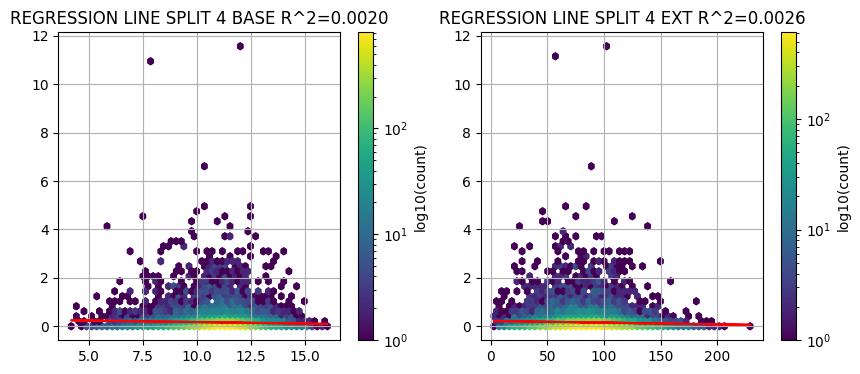

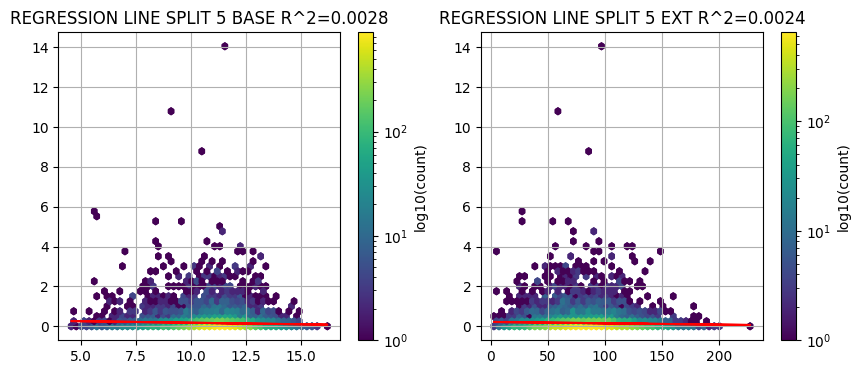

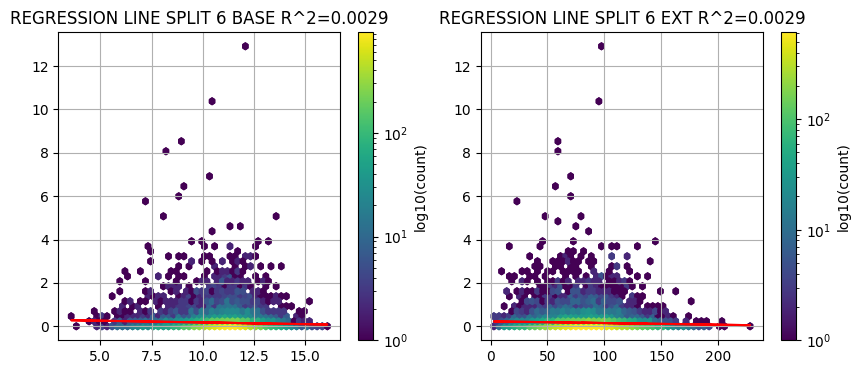

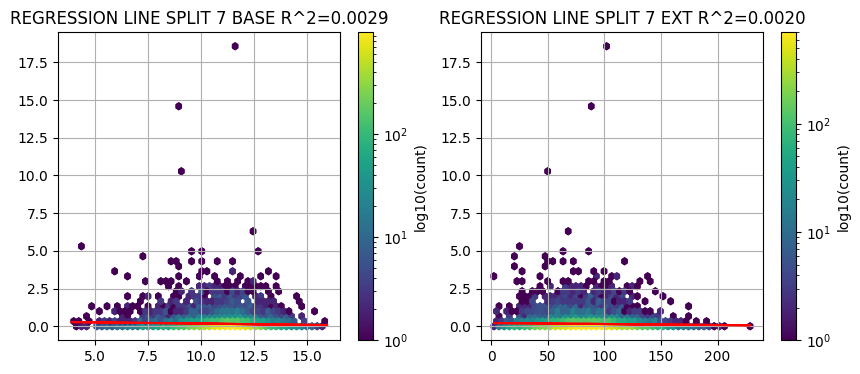

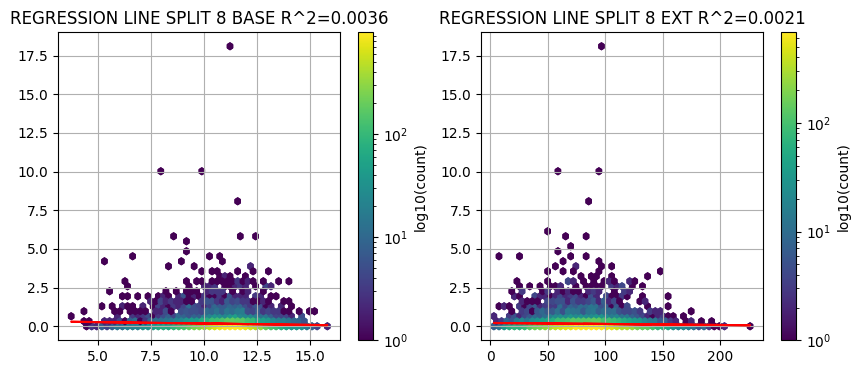

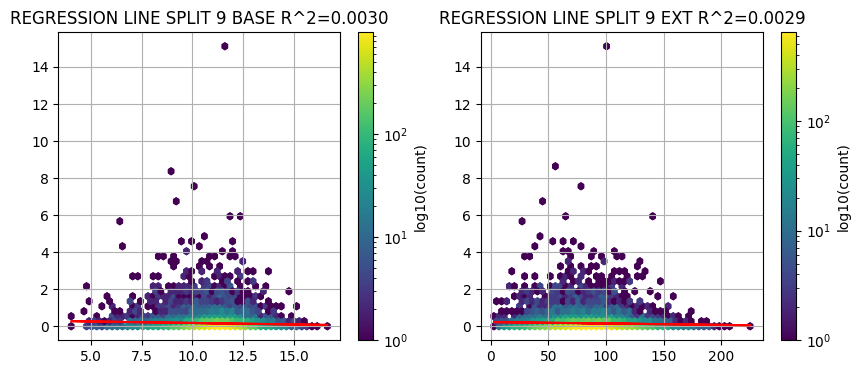

In [5]:
model_name = 'extendedDoubleEmb'

df = pd.read_csv(f'../analysis/sim_analysis/dtw_{model_name}.csv')


b_rsquared_list = []
e_rsquared_list = []

for s in df['split'].unique():
    df_tmp = df[df['split']==s]

    b_dist = df_tmp['item_dist_base'].to_numpy()
    e_dist = df_tmp['item_dist_ext'].to_numpy()
    prob = df_tmp['prob'].to_numpy()

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    
    b_dist_sm = sm.add_constant(b_dist)  
    b_model = sm.OLS(prob, b_dist_sm)    
    b_results = b_model.fit()     
    b_rsquared_list.append(b_results.rsquared)

    

    
    axes[0].plot(b_dist, b_results.predict(b_dist_sm), label=f'Split {s} base emb', color='red')
    axes[0].grid()
    axes[0].set_title(f'REGRESSION LINE SPLIT {s} BASE R^2={b_results.rsquared:.4f}')
    axes[0].hexbin(x=df_tmp['item_dist_base'], y=df_tmp['prob'],gridsize=50, cmap="viridis", bins='log')

    hb = axes[0].hexbin(
                x=df_tmp['item_dist_base'],
                y=df_tmp['prob'],
                gridsize=50,
                cmap="viridis",
                bins='log'
            )

    fig.colorbar(hb, ax=axes[0], label='log10(count)')

    
    e_dist_sm = sm.add_constant(e_dist)  
    e_model = sm.OLS(prob, e_dist_sm)    
    e_results = e_model.fit()     
    e_rsquared_list.append(e_results.rsquared)

    

    
    axes[1].plot(e_dist, e_results.predict(e_dist_sm), label=f'Split {s} base ext', color='red')
    axes[1].grid()
    axes[1].set_title(f'REGRESSION LINE SPLIT {s} EXT R^2={e_results.rsquared:.4f}')
    axes[1].hexbin(x=df_tmp['item_dist_ext'], y=df_tmp['prob'],gridsize=50, cmap="viridis", bins='log')

    hb = axes[1].hexbin(
                x=df_tmp['item_dist_ext'],
                y=df_tmp['prob'],
                gridsize=50,
                cmap="viridis",
                bins='log'
            )

    fig.colorbar(hb, ax=axes[1], label='log10(count)')



print(f'MODEL {model_name}')
print(f'R_SQUARED BASE: {np.mean(b_rsquared_list):.5f} ± {1.96*np.std(b_rsquared_list):.5f}')
print(f'R_SQUARED EXT: {np.mean(e_rsquared_list):.5f} ± {1.96*np.std(e_rsquared_list):.5f}')

In [6]:
model_name = 'extendedDoubleEmbFreeze'

df = pd.read_csv(f'../analysis/sim_analysis/dtw_{model_name}.csv')


b_rsquared_list = []
e_rsquared_list = []

for s in df['split'].unique():
    df_tmp = df[df['split']==s]

    b_dist = df_tmp['item_dist_base'].to_numpy()
    e_dist = df_tmp['item_dist_ext'].to_numpy()
    prob = df_tmp['prob'].to_numpy()

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    
    b_dist_sm = sm.add_constant(b_dist)  
    b_model = sm.OLS(prob, b_dist_sm)    
    b_results = b_model.fit()     
    b_rsquared_list.append(b_results.rsquared)

    

    
    axes[0].plot(b_dist, b_results.predict(b_dist_sm), label=f'Split {s} base emb', color='red')
    axes[0].grid()
    axes[0].set_title(f'REGRESSION LINE SPLIT {s} BASE R^2={b_results.rsquared:.4f}')
    axes[0].hexbin(x=df_tmp['item_dist_base'], y=df_tmp['prob'],gridsize=50, cmap="viridis", bins='log')

    hb = axes[0].hexbin(
                x=df_tmp['item_dist_base'],
                y=df_tmp['prob'],
                gridsize=50,
                cmap="viridis",
                bins='log'
            )

    fig.colorbar(hb, ax=axes[0], label='log10(count)')

    
    e_dist_sm = sm.add_constant(e_dist)  
    e_model = sm.OLS(prob, e_dist_sm)    
    e_results = e_model.fit()     
    e_rsquared_list.append(e_results.rsquared)

    

    
    axes[1].plot(e_dist, e_results.predict(e_dist_sm), label=f'Split {s} base ext', color='red')
    axes[1].grid()
    axes[1].set_title(f'REGRESSION LINE SPLIT {s} EXT R^2={e_results.rsquared:.4f}')
    axes[1].hexbin(x=df_tmp['item_dist_ext'], y=df_tmp['prob'],gridsize=50, cmap="viridis", bins='log')

    hb = axes[1].hexbin(
                x=df_tmp['item_dist_ext'],
                y=df_tmp['prob'],
                gridsize=50,
                cmap="viridis",
                bins='log'
            )

    fig.colorbar(hb, ax=axes[1], label='log10(count)')



print(f'MODEL {model_name}')
print(f'R_SQUARED BASE: {np.mean(b_rsquared_list):.5f} ± {1.96*np.std(b_rsquared_list):.5f}')
print(f'R_SQUARED EXT: {np.mean(e_rsquared_list):.5f} ± {1.96*np.std(e_rsquared_list):.5f}')

FileNotFoundError: [Errno 2] No such file or directory: '../analysis/sim_analysis/dtw_extendedDoubleEmbFreeze.csv'